# Setting Up an AnnData Object
- using paper/examples/lympnhnode_analysis.ipynb

In [1]:
# Import functions from the updated SPAC package
from spac.data_utils import load_csv_files, ingest_cells
from spac.phenotyping import assign_manual_phenotypes
from spac.spatial_analysis import spatial_interaction
from spac.leiden_clustering import preprocess, leiden_only_clustering, plot

# Import libraries
import numpy as np
import pandas as pd
from math import ceil, sqrt
import matplotlib.pyplot as plt
import seaborn as sns 
import copy
import anndata
import scanpy as sc
import plotly.io as pio
from PIL import Image as PILImage
from pprint import pprint
from io import BytesIO
%matplotlib inline

# Reduce verbosity settings
import warnings
warnings.filterwarnings('ignore')

# Configure root logger to suppress INFO
# Set logging to only show warnings and errors
import logging
import sys
logging.getLogger().setLevel(logging.WARNING)

# Configure specific loggers
logging.getLogger('spac').setLevel(logging.WARNING)
logging.getLogger('spac.utils').setLevel(logging.WARNING)  # In case of sub-loggers
logging.getLogger('spac.visualization').setLevel(logging.WARNING)

# Also disable propagation to root logger
logging.getLogger('spac').propagate = False

# For scanpy verbosity
sc.settings.verbosity = 1  # Only show errors
# Set visualization parameters
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Suppress matplotlib debug messages
logging.getLogger('matplotlib').setLevel(logging.WARNING)

/home/x-rprasanna/.local/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/x-rprasanna/.local/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/x-rprasanna/.local/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/x-rpras

In [2]:
# Setup working directory and file paths
data_csv = "../paper/examples/example_lymphnode_data.csv"

In [3]:
def generate_grid_frame(adata, fig_width=12, fig_height=12, dpi=300, n_plots=None):
    """Generate a grid frame for multiple subplots."""
    if n_plots is None:
        n_annotations = len(adata.obs.columns.tolist())
    else:
        n_annotations = n_plots
    
    n_cols = ceil(sqrt(n_annotations))
    n_rows = ceil(n_annotations / n_cols)
    
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(fig_width, fig_height),
        dpi=dpi
    )
    axes = axes.flatten()
    return fig, axes

In [4]:
# Load data without verbose output
import io
import contextlib

file_names = [data_csv]

# Suppress all output from load_csv_files
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    data = load_csv_files(file_names)

# Get the dataframe
df = data[0] if isinstance(data, list) else data

# Print only your custom summary
print(f"✓ Dataset loaded: {df.shape[0]} cells × {df.shape[1]} features")
print(f"✓ Marker columns: {sum(col not in ['CellID', 'X_centroid', 'Y_centroid'] for col in df.columns)} markers")

✓ Dataset loaded: 4825 cells × 85 features
✓ Marker columns: 82 markers


In [5]:
# Define the manual phenotype codes and names
phenotype_definitions = pd.DataFrame([
    {"phenotype_code": "CD3D+CD4+FOXP3+", "phenotype_name": "Regulatory T Cell"},
    {"phenotype_code": "CD3D+CD4+", "phenotype_name": "Helper T Cell"},
    {"phenotype_code": "CD3D+CD8A+", "phenotype_name": "Cytotoxic T Cell"},
    {"phenotype_code": "CD3D+", "phenotype_name": "T Cell"},
    {"phenotype_code": "CD20+", "phenotype_name": "B Cell"},
    {"phenotype_code": "CD21+CD20-", "phenotype_name": "Follicular Dendritic Cell"},
    {"phenotype_code": "CD56+", "phenotype_name": "NK Cell"},
    {"phenotype_code": "CD68+", "phenotype_name": "CD68+ Macrophage"},
    {"phenotype_code": "CD11C+", "phenotype_name": "Dendritic Cell"},
    {"phenotype_code": "CD15+", "phenotype_name": "Granulocyte"},
    {"phenotype_code": "KI67+", "phenotype_name": "Proliferating Cell"},
    {"phenotype_code": "PD1+", "phenotype_name": "Activated T/B Cell"},
    {"phenotype_code": "HLADR+", "phenotype_name": "Activated APC"},
    {"phenotype_code": "CD163+", "phenotype_name": "CD163+ Macrophage"}
])

# Apply manual phenotyping with suppressed output
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    assign_manual_phenotypes(df, phenotype_definitions, suffix="_expression")
    
# Print custom output
print("✓ Manual phenotypes assigned successfully!")
print(f"  - Added {len(phenotype_definitions)} phenotype definitions")
print(f"  - Processed {len(df)} cells")

✓ Manual phenotypes assigned successfully!
  - Added 14 phenotype definitions
  - Processed 4825 cells


In [6]:
# Define features to include in analysis
feature_names = [
    "CD25", "CD2", "CD10", "CD163", "CD3D", "CD5", "CD30", "ACTIN", "CD45",
    "CD206", "CD68", "PD1", "KI67", "CD11C", "CD7", "CD8A", "FOXP3", "CD20",
    "CD4", "HLADR", "PSTAT3", "PS6", "PERK", "CD21", "CD43", "NOS2", "PDL1",
    "CD11B", "CD57", "MHCI", "CD15", "ASMA", "CD56"
]

# Create regex patterns for feature selection
regex_str = [f"^{feature}$" for feature in feature_names]

# Define spatial coordinates and annotations
x_col = "X_centroid"
y_col = "Y_centroid"
annotation = ["broad_cell_type", "detailed_cell_type", "manual_phenotype"]

# Create AnnData object
adata = ingest_cells(
    dataframe=df,
    regex_str=regex_str,
    x_col=x_col,
    y_col=y_col,
    annotation=annotation
)

print(f"AnnData object created: {adata}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of features: {adata.n_vars}")

^CD25$
^CD2$
^CD10$
^CD163$
^CD3D$
^CD5$
^CD30$
^ACTIN$
^CD45$
^CD206$
^CD68$
^PD1$
^KI67$
^CD11C$
^CD7$
^CD8A$
^FOXP3$
^CD20$
^CD4$
^HLADR$
^PSTAT3$
^PS6$
^PERK$
^CD21$
^CD43$
^NOS2$
^PDL1$
^CD11B$
^CD57$
^MHCI$
^CD15$
^ASMA$
^CD56$
AnnData object created: AnnData object with n_obs × n_vars = 4825 × 33
    obs: 'broad_cell_type', 'detailed_cell_type', 'manual_phenotype'
    obsm: 'spatial'
Number of cells: 4825
Number of features: 33


# Running Leiden Clustering

In [7]:
# Preprocess once, reuse for multiple clustering runs
ad_prep = preprocess(adata)

# ad_prep now contains PCA, neighbors, and UMAP
print(ad_prep.obsm.keys())
print('neighbors' in ad_prep.uns)

2026-04-28 15:41:43.210070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777405303.378333     850 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777405303.422346     850 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777405303.870425     850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777405303.870569     850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777405303.870572     850 computation_placer.cc:177] computation placer alr

KeysView(AxisArrays with keys: spatial, X_pca, X_umap)
True


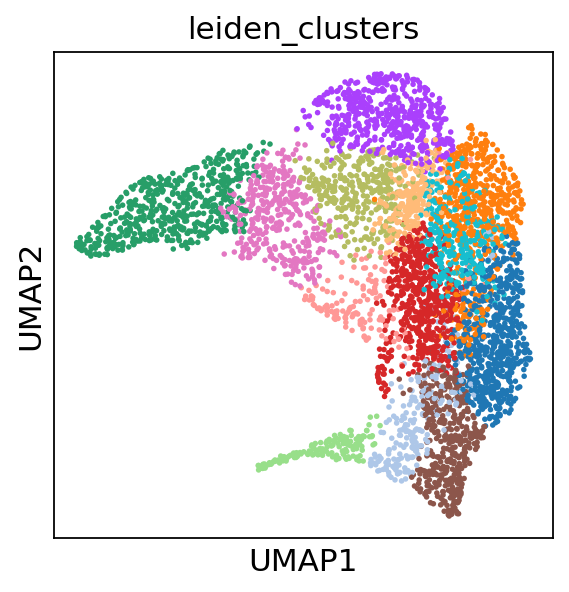

In [8]:
# Here is a basic plot without any tuned parameters
ad_clustered = leiden_only_clustering(ad_prep)
plot(ad_clustered)

## Resolution Tuning
- The resolution parameter is the most important knob for biological interpretability.
- Use low values for broad cell populations and high values for fine-grained sub-populations

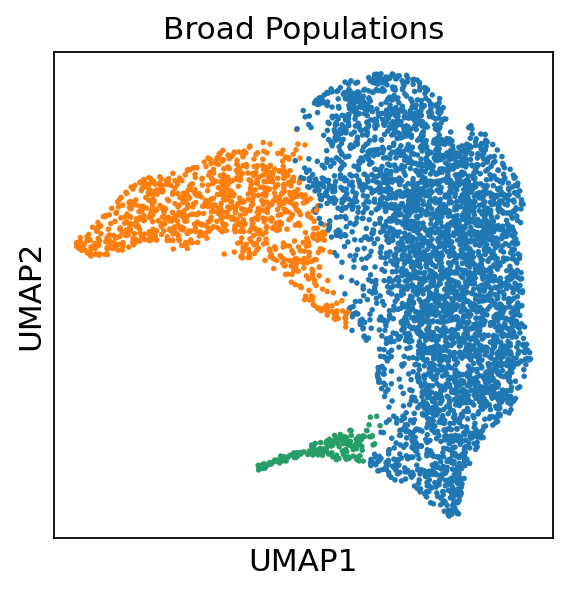

In [9]:
# low resolution (broad)

ad_broad = leiden_only_clustering(
    ad_prep,
    resolution=0.1,
    key_added="clusters_broad"
)
plot(ad_broad,
     color="clusters_broad",
     title="Broad Populations")

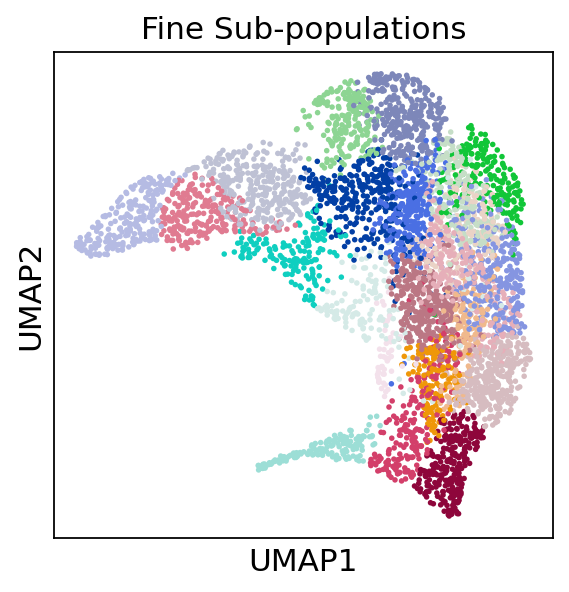

In [10]:
# high resolution (fine)

ad_fine = leiden_only_clustering(
    ad_prep,
    resolution=2.0,
    key_added="clusters_fine"
)
plot(ad_fine,
     color="clusters_fine",
     title="Fine Sub-populations")

In [11]:
# Checking cluster counts programmatically before plotting

for res in [0.1, 0.5, 1.0, 2.0]:
    ad_tmp = leiden_only_clustering(ad_prep, resolution=res)
    n = ad_tmp.obs["leiden_clusters"].nunique()
    print(f"resolution={res:.1f} → {n} clusters")

resolution=0.1 → 3 clusters
resolution=0.5 → 9 clusters
resolution=1.0 → 13 clusters
resolution=2.0 → 22 clusters


## Coloring by Other Annotations
- Because plot() accepts any adata.obs column as color
- You can overlay the UMAP with any annotation already on the object, including SPAC's manual phenotypes

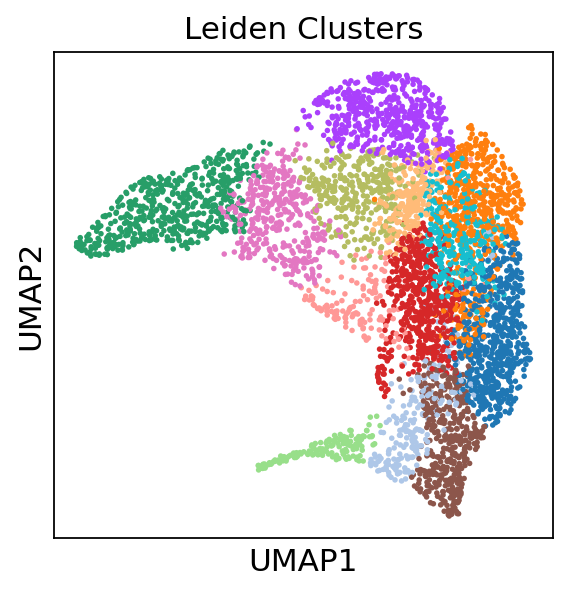

In [12]:
# Show leiden clusters on the UMAP
plot(ad_clustered, color="leiden_clusters", title="Leiden Clusters")

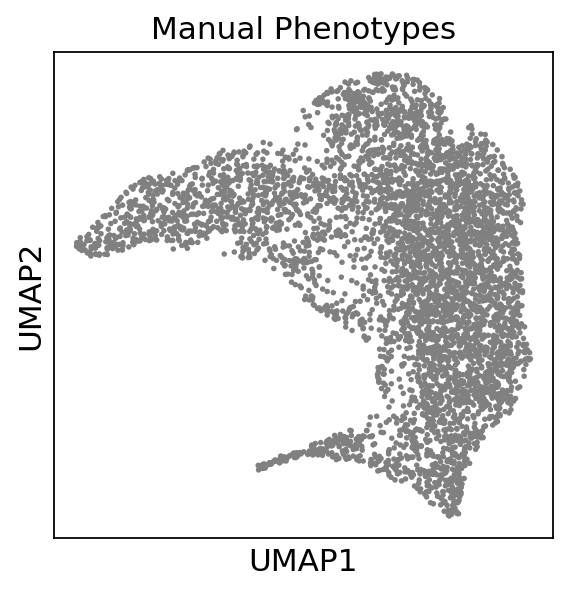

In [13]:
# Show manual phenotypes on the same UMAP embedding
plot(ad_clustered, color="manual_phenotype", title="Manual Phenotypes")

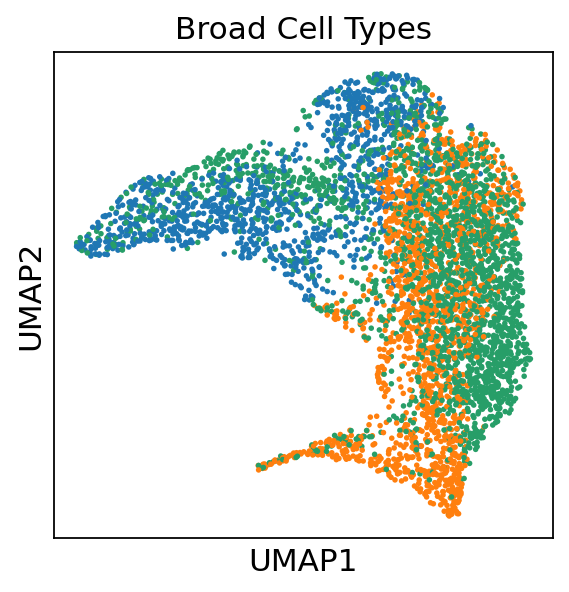

In [14]:
# Show broad cell types
plot(ad_clustered, color="broad_cell_type", title="Broad Cell Types")

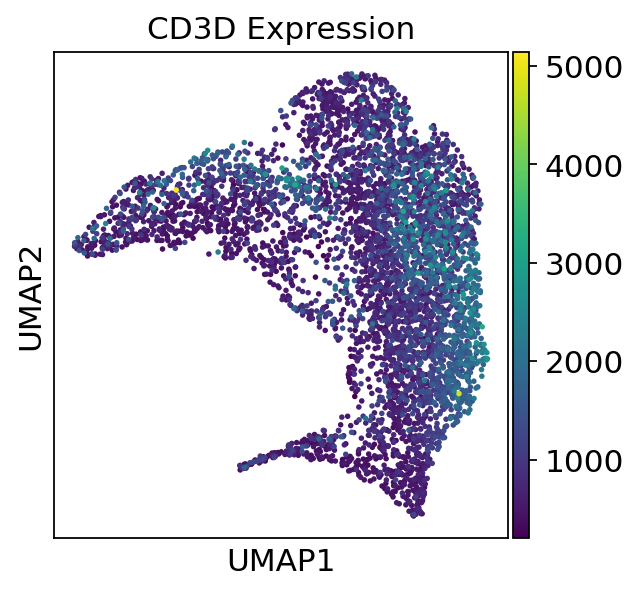

In [15]:
# Color by CD3D expression level across cells
plot(ad_clustered, color="CD3D", title="CD3D Expression")

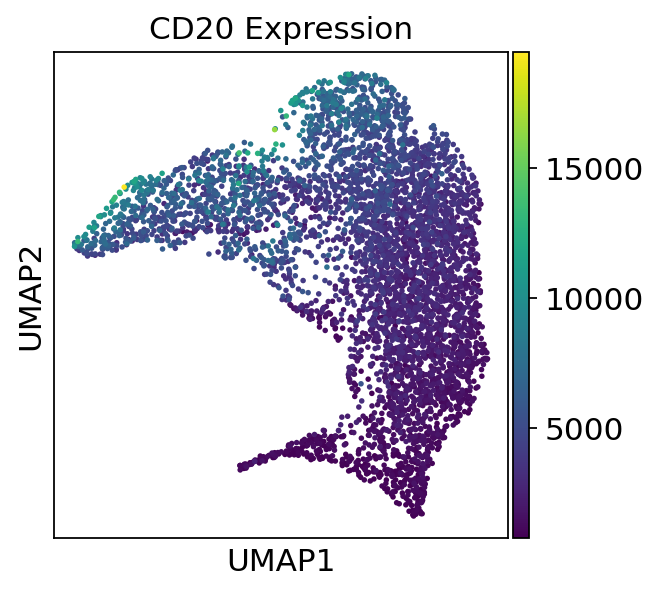

In [16]:
# Color by CD20 expression level across cells
plot(ad_clustered, color="CD20", title="CD20 Expression")

## Multi-Resolution Grid
- Use the notebook's generate_grid_frame() helper with sc.pl.umap(ax=) to embed multiple resolutions in a single matplotlib figure.

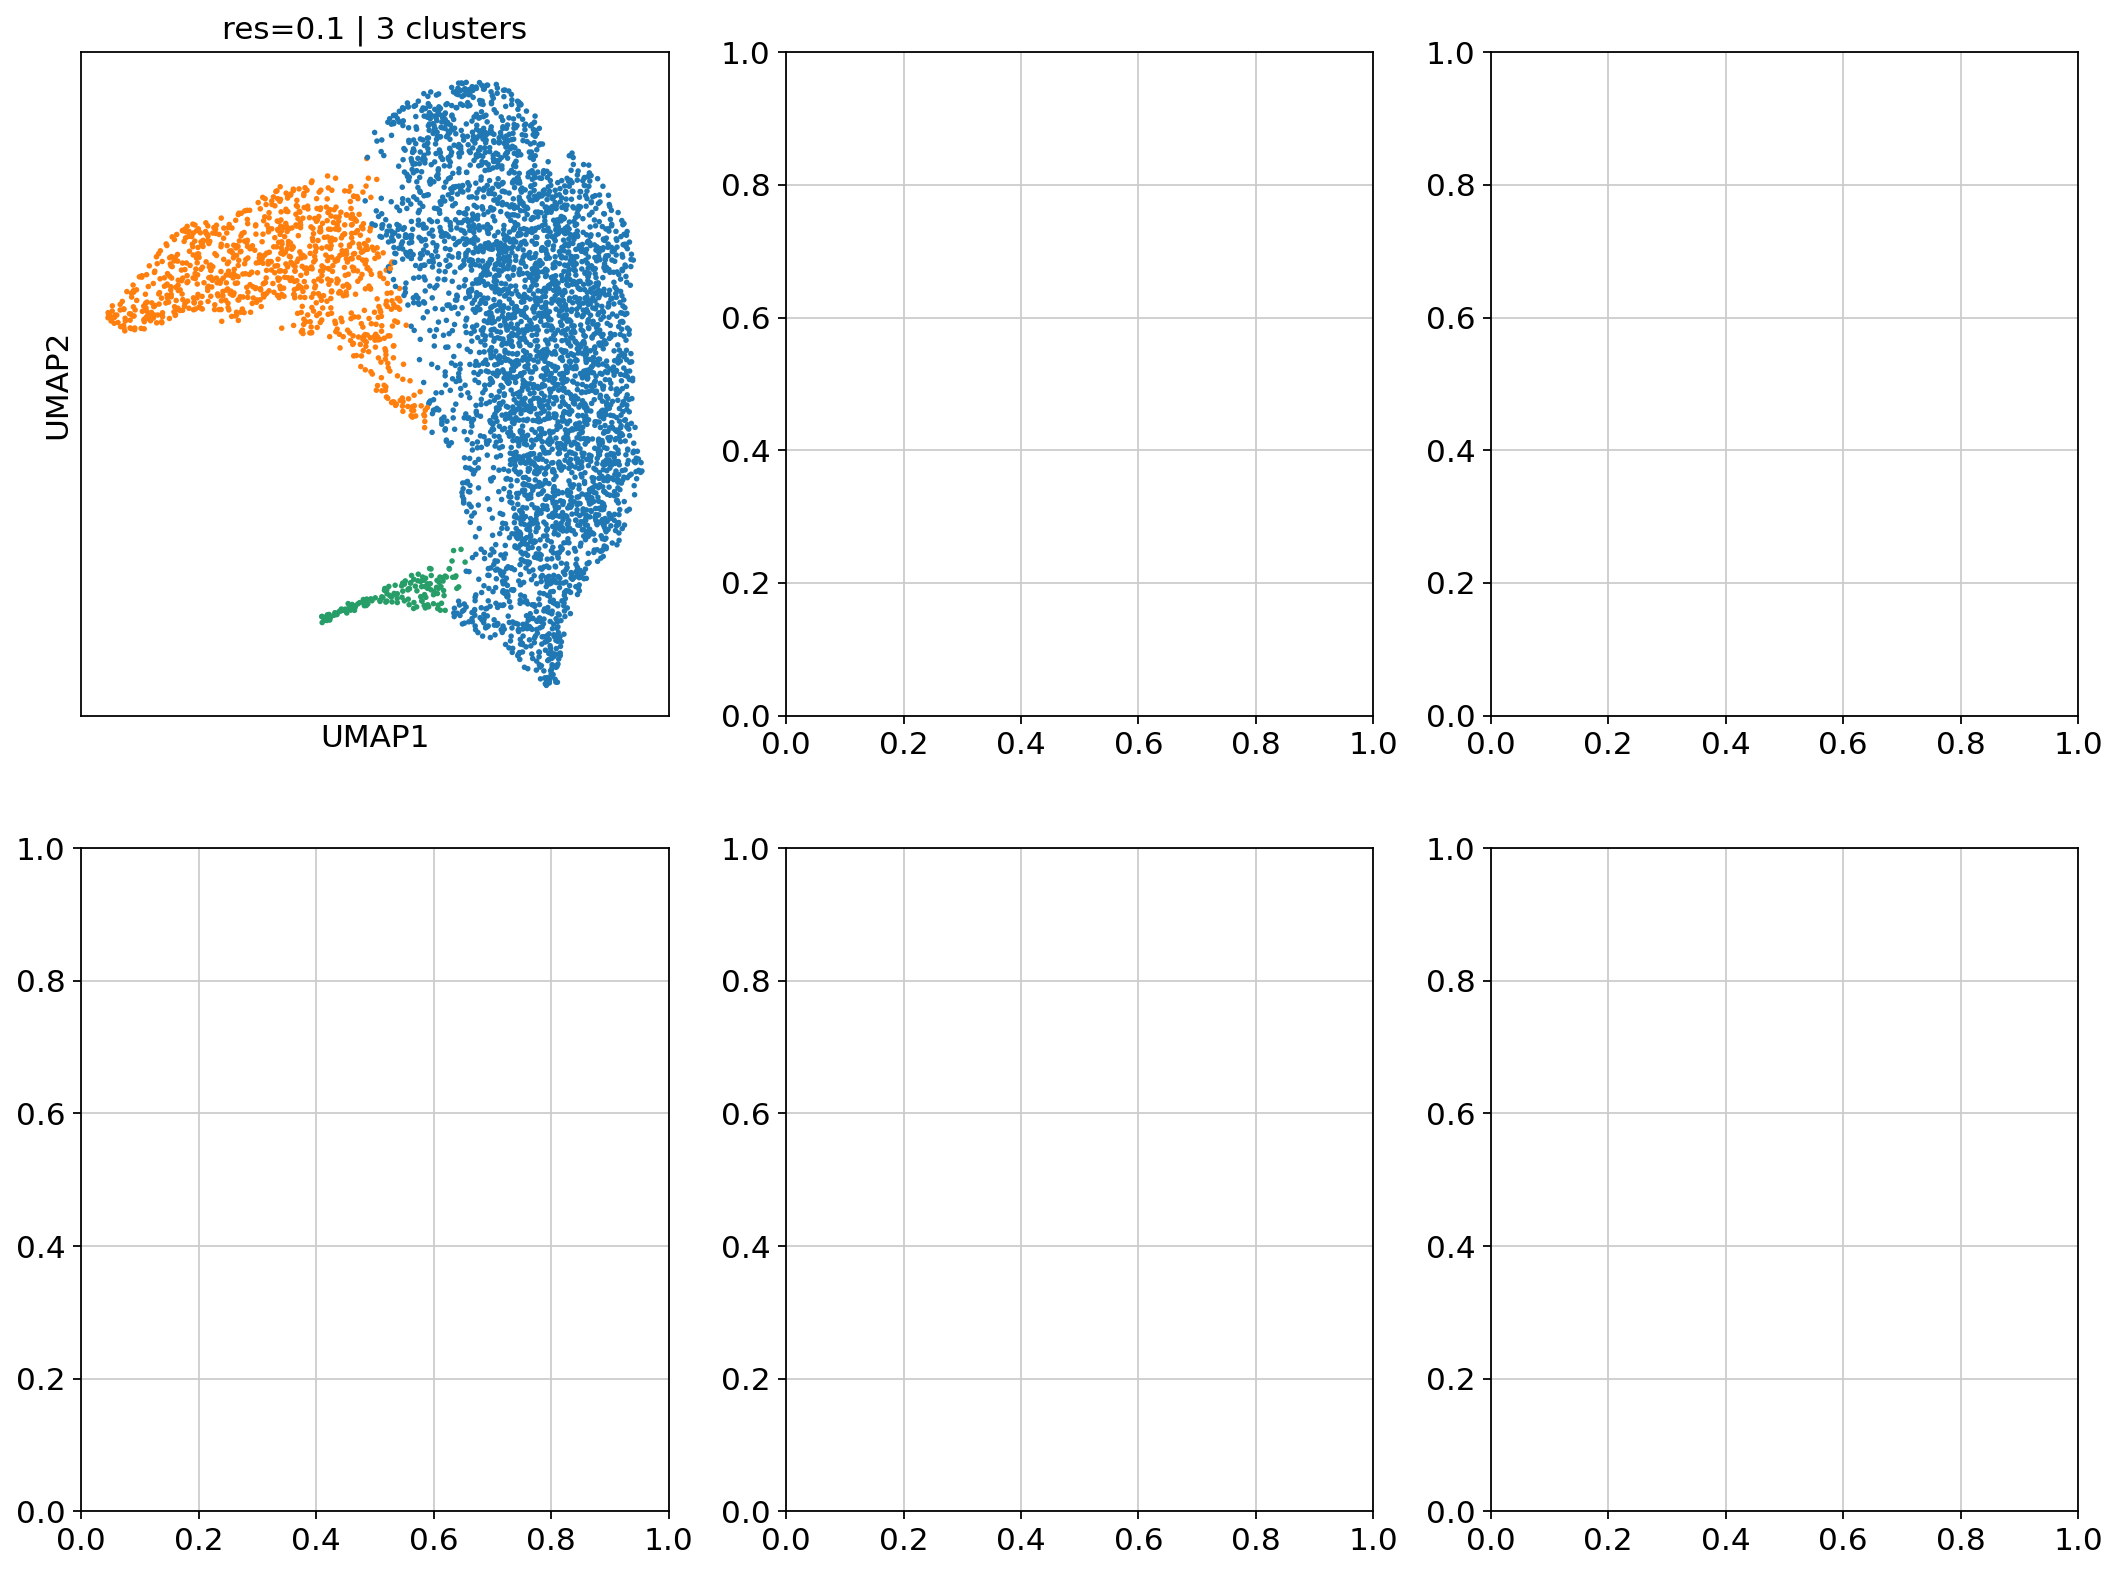

<Figure size 320x320 with 0 Axes>

In [17]:
# define resolutions
resolutions = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
n = len(resolutions)

# compute grid dimensions that fit all resolutions as squarely as possible
n_cols = ceil(sqrt(n))
n_rows = ceil(n / n_cols)

# create a single figure with one subplot per resolution
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()  # convert 2D grid to 1D so we can index with i

for i, res in enumerate(resolutions):
    # run clustering at this resolution — ad_prep is reused so PCA/UMAP
    # is not recomputed each iteration, only the Leiden partition changes
    ad_tmp = leiden_only_clustering(
        ad_prep,
        resolution=res,
        key_added="leiden_clusters"
    )
    n_clusters = ad_tmp.obs["leiden_clusters"].nunique()

    # draw this resolution's UMAP into its dedicated subplot
    plot(
        ad_tmp,
        color="leiden_clusters",
        title=f"res={res} | {n_clusters} clusters",  # title shows tradeoff at a glance
        ax=axes[i]
    )

# subplots beyond the last resolution are empty — hide them
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("resolution_grid.png", dpi=150)

## SPAC Integration Patterns
- Leiden clustering sits naturally between data loading / phenotyping and spatial analysis in the SPAC pipeline

  0%|          | 0/1000 [00:00<?, ?/s]

{'Ax': <Axes: >}

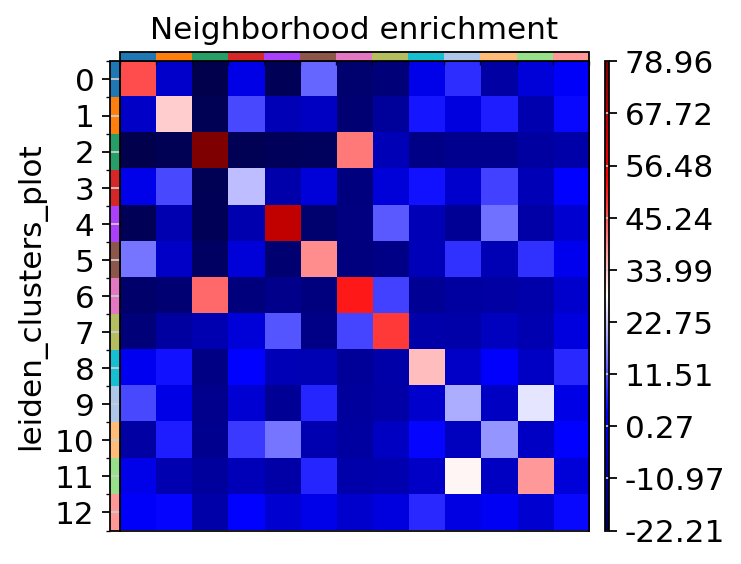

In [26]:
# Feeding Leiden clusters into spatial_interaction -----------------

# Run clustering with a named key
ad_clustered = leiden_only_clustering(
    ad_prep,
    resolution=1.0,
    key_added="leiden_clusters"
)

# Use those clusters to compute cell-cell interaction enrichment
spatial_interaction(
    ad_clustered,
    annotation="leiden_clusters",
    analysis_method="Neighborhood Enrichment"
)

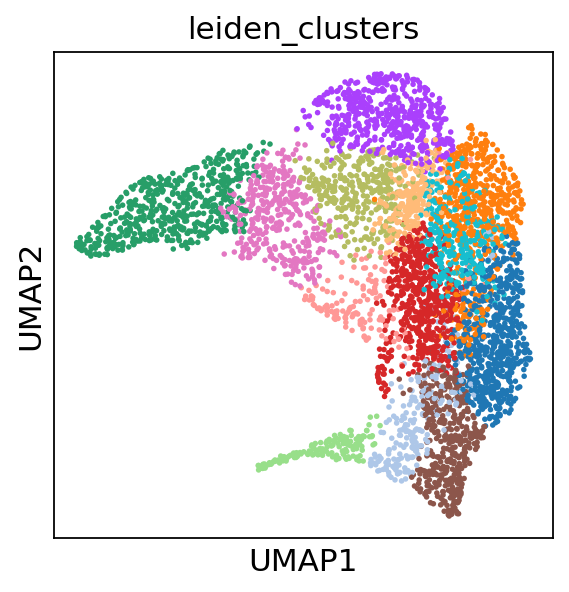

Running visualization using the coordinates: "X_umap"
Cluster: 0, Points: 584
Cluster: 1, Points: 541
Cluster: 2, Points: 537
Cluster: 3, Points: 524
Cluster: 4, Points: 501
Cluster: 5, Points: 436
Cluster: 6, Points: 367
Cluster: 7, Points: 324
Cluster: 8, Points: 276
Cluster: 9, Points: 225
Cluster: 10, Points: 219
Cluster: 11, Points: 149
Cluster: 12, Points: 142


(<Figure size 800x640 with 1 Axes>,
 <Axes: title={'center': 'UMAP-leiden_clusters'}, xlabel='UMAP 1', ylabel='UMAP 2'>)

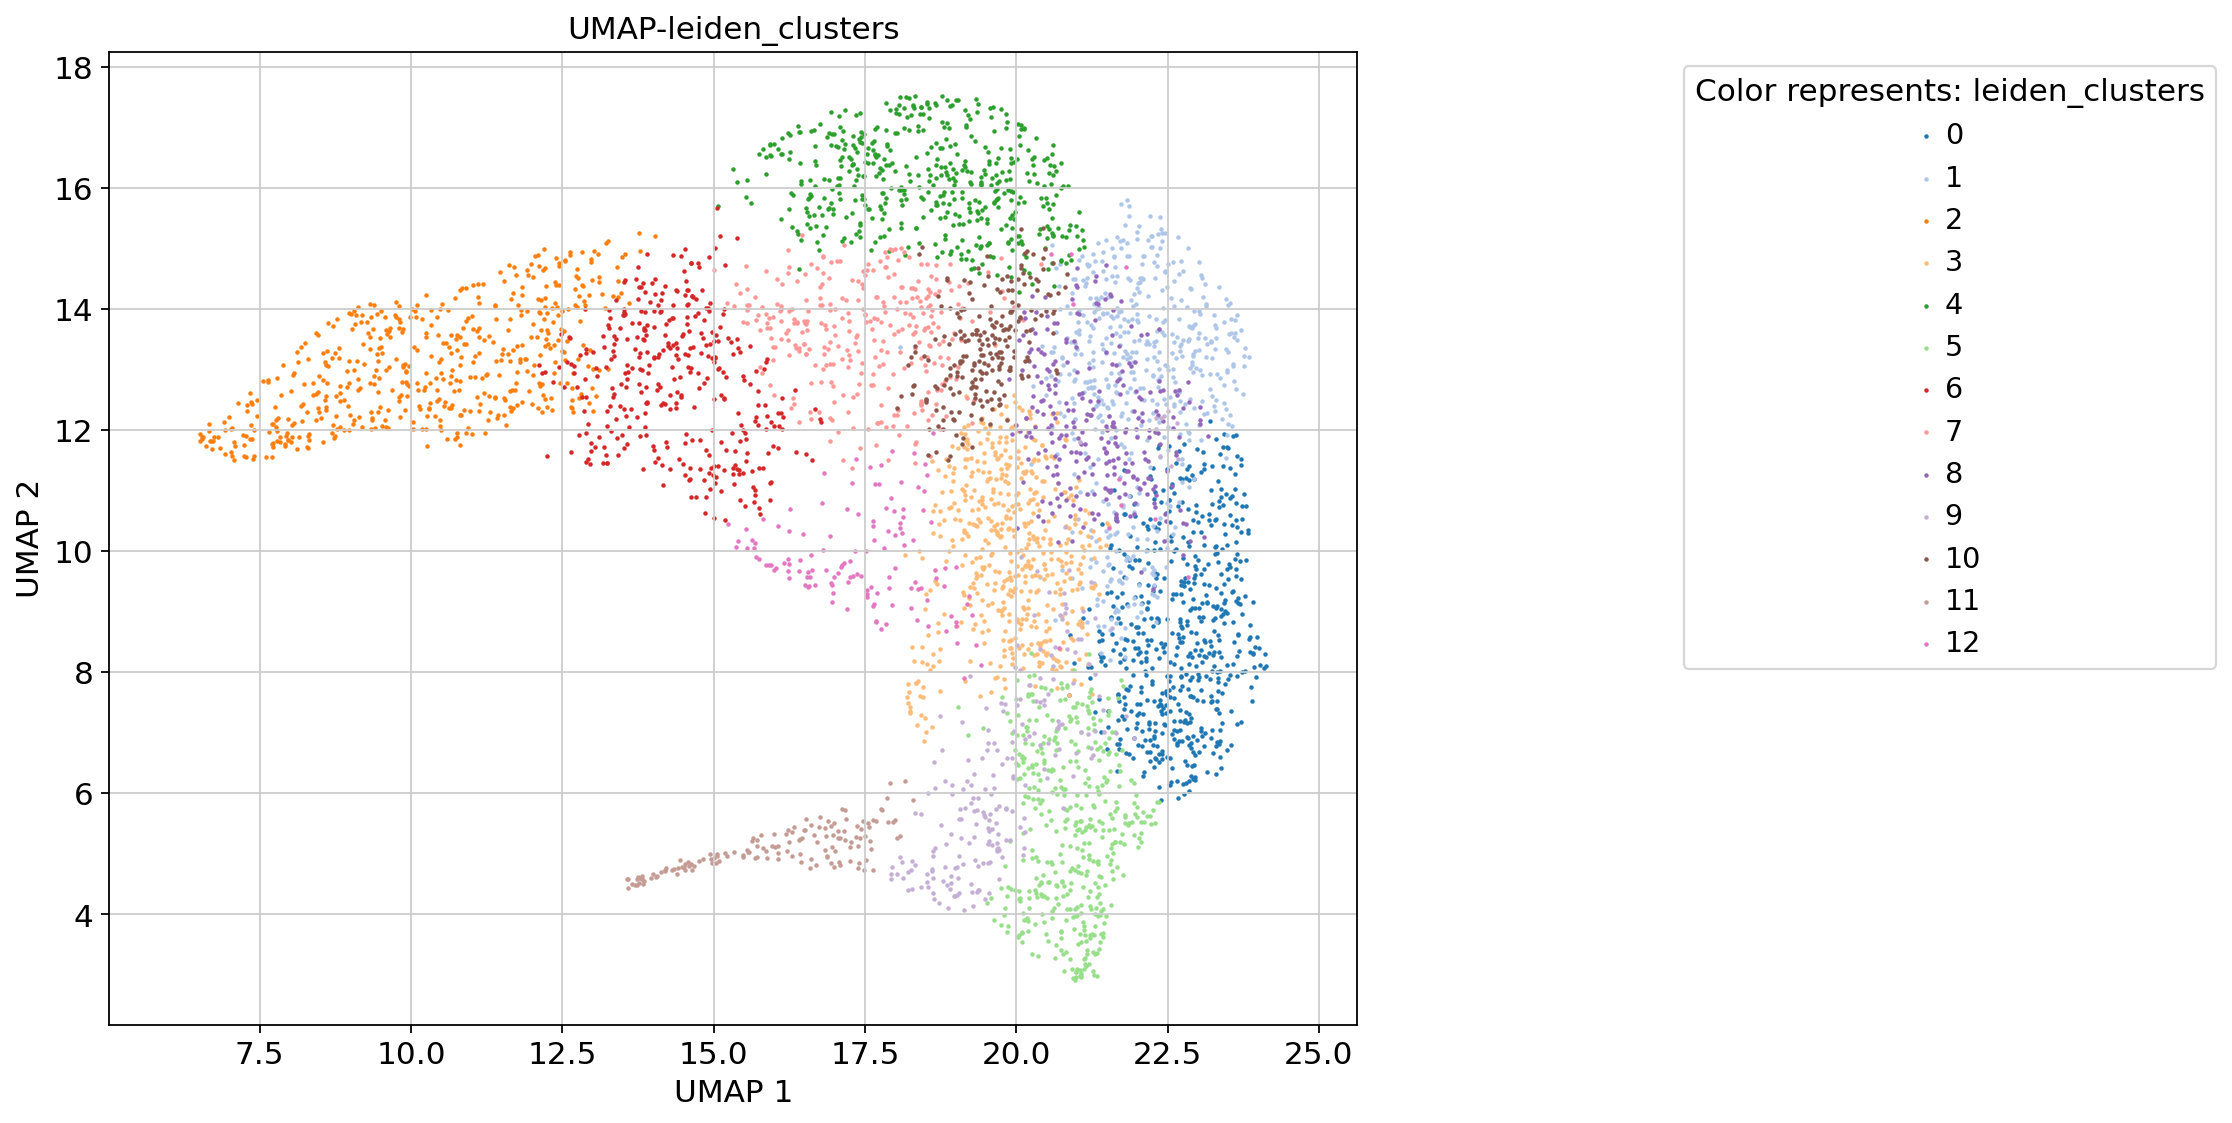

In [23]:
# Combining with dimensionality_reduction_plot ------------------

from spac.visualization import dimensionality_reduction_plot

# After Leiden clustering, compare UMAP embeddings
# plot() uses the internal UMAP from preprocessing
plot(ad_clustered, color="leiden_clusters")

# SPAC's dimensionality_reduction_plot can use the same adata
dimensionality_reduction_plot(
    ad_clustered,
    annotation="leiden_clusters",
    method="umap"
)

## Saving Outputs
- Scanpy saves figures to a figures/ directory in the working directory. The save parameter is appended as a suffix to "umap"

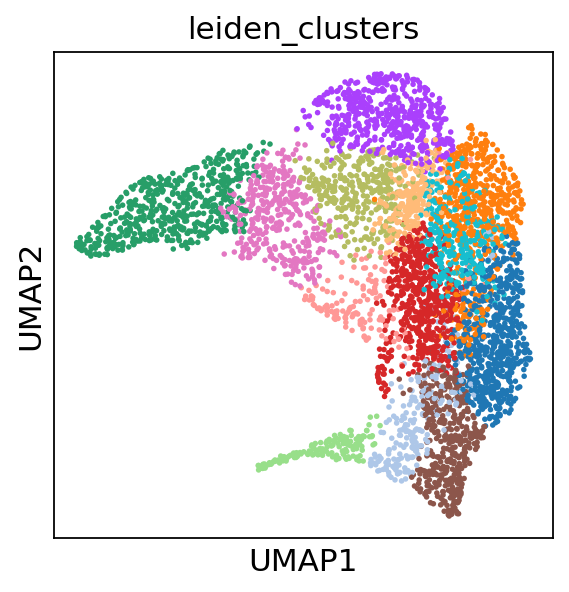

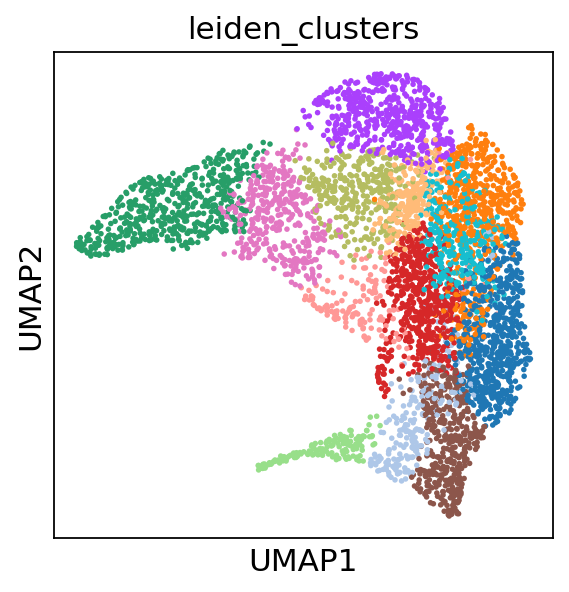

In [27]:
# Save plot ------------------------------------

# Saves to figures/umap_leiden_results.png
plot(ad_clustered, save="_leiden_results.png")

# Custom save path via sc.settings
import scanpy as sc
sc.settings.figdir = "output_dir/"
plot(ad_clustered, save="_experiment_1.pdf")
# → output_dir/umap_experiment_1.pdf

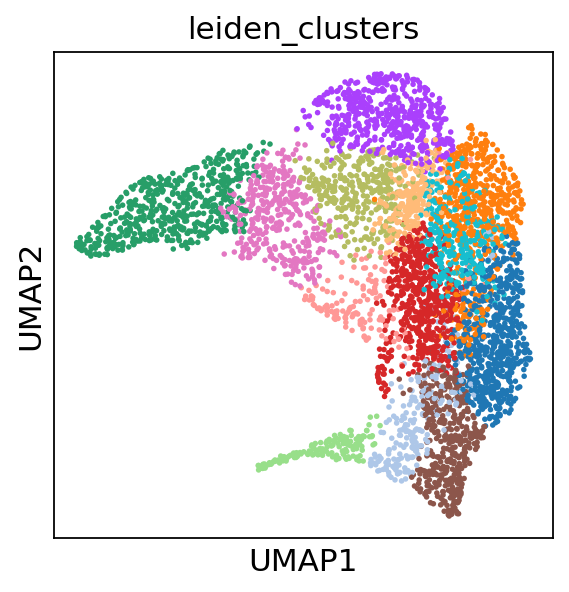

In [28]:
# To save the clustered AnnData itself for later sessions

# Save to h5ad for fast reload
ad_clustered.write("lymphnode_clustered.h5ad")

# Reload in another session
import anndata
ad = anndata.read_h5ad("lymphnode_clustered.h5ad")
plot(ad, color="leiden_clusters")